In [ ]:
import os
import numpy as np
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# --- Step 1: Download dataset using kagglehub ---
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("akhilnshukla/music-mood-spectrogram")
print("Path to dataset files:", dataset_path)

# --- Step 2: Set training parameters ---
img_height, img_width = 128, 128
batch_size = 32
epochs = 60
num_classes = 5

# --- Step 3: Prepare data generators ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# --- Step 4: Build CNN model ---
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Step 5: Train the model ---
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[checkpoint]
)

# Save final model
model.save("final_model.h5")
print("Model training completed and saved!")


100%|██████████| 1.92G/1.92G [00:17<00:00, 116MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/akhilnshukla/music-mood-spectrogram/versions/1
Found 8109 images belonging to 5 classes.
Found 2024 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2247 - loss: 1.8781

...

254/254 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.2534 - loss: 1.5525 - val_accuracy: 0.2406 - val_loss: 1.6474
Epoch 45/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.2587 - loss: 1.5578 - val_accuracy: 0.2292 - val_loss: 1.6497
Epoch 46/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.2502 - loss: 1.5519 - val_accuracy: 0.2357 - val_loss: 1.6278
Epoch 47/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.2537 - loss: 1.5516 - val_accuracy: 0.2312 - val_loss: 1.6277
Epoch 48/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.2558 - loss: 1.5440 - val_accuracy: 0.2263 - val_loss: 1.7193
Epoch 49/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2654 - loss: 1.5413

254/254 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.2653 - loss: 1.5413 - val_accuracy: 0.2431 - val_loss: 1.6965
Epoch 50/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.2653 - loss: 1.5334 - val_accuracy: 0.2357 - val_loss: 1.7521
Epoch 51/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2679 - loss: 1.5316

254/254 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.2679 - loss: 1.5316 - val_accuracy: 0.2505 - val_loss: 1.6789
Epoch 52/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.2616 - loss: 1.5266 - val_accuracy: 0.2386 - val_loss: 1.7542
Epoch 53/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.2655 - loss: 1.5239 - val_accuracy: 0.2337 - val_loss: 1.7598
Epoch 54/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.2790 - loss: 1.5054 - val_accuracy: 0.2391 - val_loss: 1.6578
Epoch 55/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.2790 - loss: 1.4927 - val_accuracy: 0.2372 - val_loss: 1.7514
Epoch 56/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.2778 - loss: 1.4910 - val_accuracy: 0.2302 - val_loss: 1.7121
Epoch 57/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.2784 - loss: 1.4734 - val_accuracy: 0.2223 - val_loss: 1.7233
Epoch 58/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.3039 - loss: 1.4533 - val_accuracy

254/254 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.3203 - loss: 1.4334 - val_accuracy: 0.2792 - val_loss: 1.7644
Epoch 60/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.3177 - loss: 1.4228 - val_accuracy: 0.2678 - val_loss: 1.7027


Model training completed and saved!


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import os
import numpy as np
import joblib

# Limit the number of images per class to speed up
MAX_IMAGES_PER_CLASS = 1000  # reduce to speed up

# Load pretrained VGG16 model and cut at fc7 layer
base_model = VGG16(weights='imagenet', include_top=True)
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)  # fc2 == fc7

# Path where dataset is stored
dataset_path = kagglehub.dataset_download("akhilnshukla/music-mood-spectrogram")  # Update this path

# Extract features and labels
features = []
labels = []
class_names = sorted(os.listdir(dataset_path))

print("Extracting features using VGG-16 fc7 layer...")
for label in class_names:
    label_path = os.path.join(dataset_path, label)
    img_files = os.listdir(label_path)[:MAX_IMAGES_PER_CLASS]  # limit samples
    for img_file in img_files:
        img_path = os.path.join(label_path, img_file)
        try:
            img = load_img(img_path, target_size=(224, 224))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)
            x = preprocess_input(x)

            feat = model.predict(x)
            features.append(feat.flatten())
            labels.append(label)
        except Exception as e:
            print(f"Skipping image {img_path} due to error: {e}")

# Encode labels and train SVM
le = LabelEncoder()
y = le.fit_transform(labels)

svm = SVC(kernel='linear', probability=True)
svm.fit(features, y)

# Save model & label encoder
joblib.dump(svm, 'svm_vgg_fc7_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("✅ SVM trained and saved (on limited data).")


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━

📦 Loading models...
✅ Models loaded.


🎼 Processing: Eyy Banane - Video  _ Vaazha _ Vipin Das _ Anand Menen _ Electronic Kili _Siju Sunny _Joemon Jyothir.mp3
🎧 Processing audio: /content/Eyy Banane - Video  _ Vaazha _ Vipin Das _ Anand Menen _ Electronic Kili _Siju Sunny _Joemon Jyothir.mp3


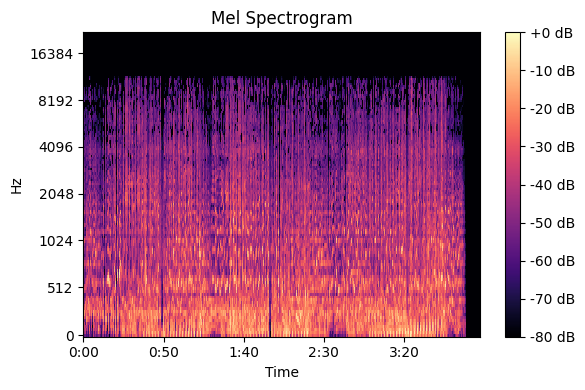

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step


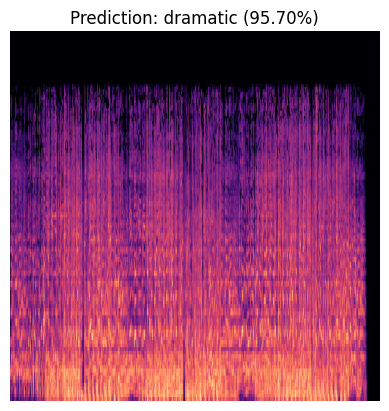

🎵 Predicted Emotion: dramatic (Confidence: 95.70%)

🎼 Processing: Rap Freestyle Type Beat - _PLAY WITH ME_ (Free Hard Trap Instrumental) (3).mp3
🎧 Processing audio: /content/Rap Freestyle Type Beat - _PLAY WITH ME_ (Free Hard Trap Instrumental) (3).mp3


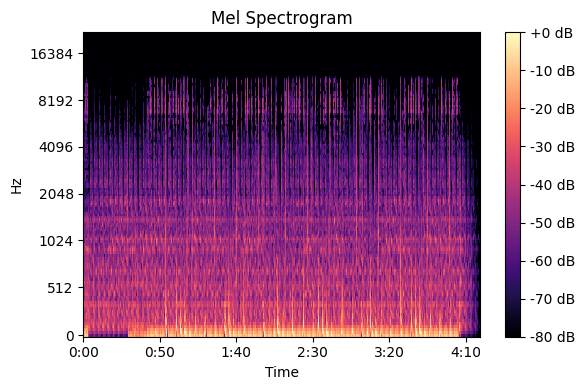

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step


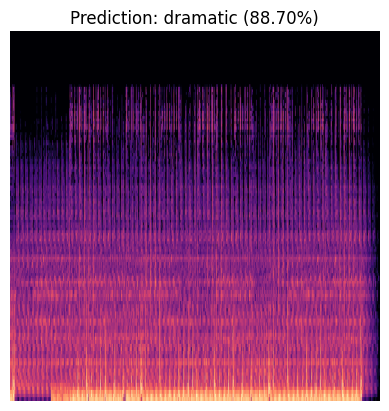

🎵 Predicted Emotion: dramatic (Confidence: 88.70%)

🎼 Processing: Mizhiyil Ninnum Lyric Video _ Mayaanadhi _ Aashiq Abu _ Rex Vijayan _ Shahabaz Aman _ Tovino Thomas-yt.savetube.me.mp3
🎧 Processing audio: /content/Mizhiyil Ninnum Lyric Video _ Mayaanadhi _ Aashiq Abu _ Rex Vijayan _ Shahabaz Aman _ Tovino Thomas-yt.savetube.me.mp3


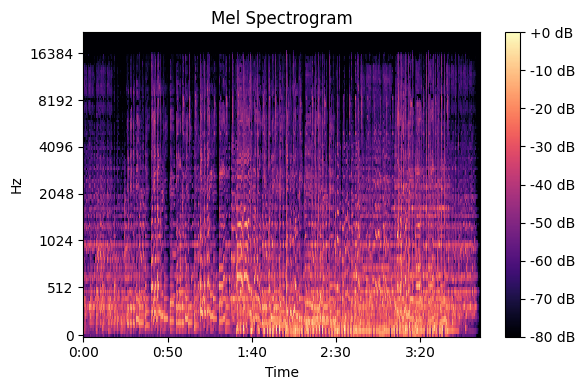

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step


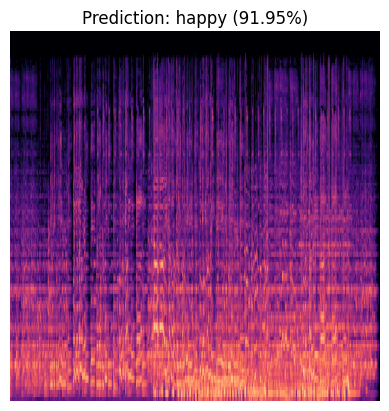

🎵 Predicted Emotion: happy (Confidence: 91.95%)

🎼 Processing: Do Patti_ Raanjhan (Full Video) Kriti Sanon, Shaheer Sheikh _ Parampara Tandon _ Sachet-Parampara.mp3
🎧 Processing audio: /content/Do Patti_ Raanjhan (Full Video) Kriti Sanon, Shaheer Sheikh _ Parampara Tandon _ Sachet-Parampara.mp3


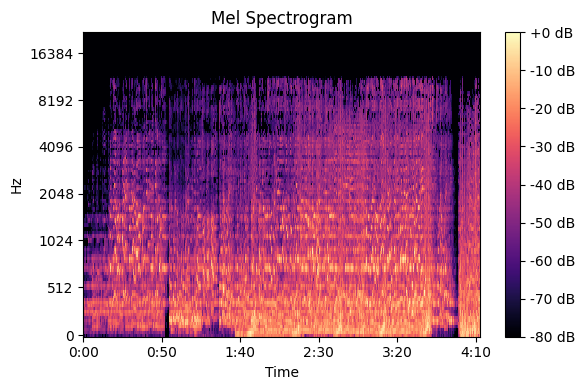

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step


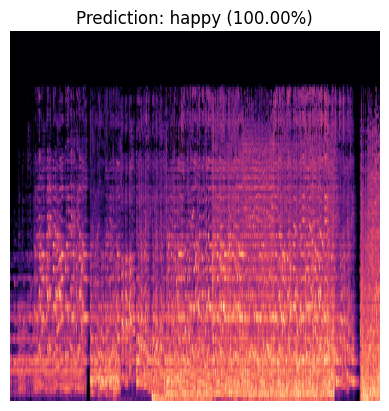

🎵 Predicted Emotion: happy (Confidence: 100.00%)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# === LOAD MODELS ===
print("📦 Loading models...")
base_model = VGG16(weights='imagenet', include_top=True)
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

svm = joblib.load("svm_vgg_fc7_model.pkl")
le = joblib.load("label_encoder.pkl")
print("✅ Models loaded.\n")

# === FUNCTION: Convert Audio to Spectrogram and Display ===
def audio_to_spectrogram(audio_path, output_image_path="spectrogram.png", show_plot=True):
    print(f"🎧 Processing audio: {audio_path}")
    y, sr = librosa.load(audio_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_DB = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(6, 6), dpi=100)
    librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_image_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    if show_plot:
        plt.figure(figsize=(6, 4))
        librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
        plt.title("Mel Spectrogram")
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.show()

    return output_image_path

# === FUNCTION: Predict Mood from Audio ===
def predict_emotion_from_audio(audio_path):
    spec_path = audio_to_spectrogram(audio_path)
    # Load audio and calculate mel spectrogram (moved outside the image loading block)
    y, sr = librosa.load(audio_path, sr=None, duration=30)  # Load first 30 seconds
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

    # Load and preprocess the spectrogram image for prediction
    img = load_img(spec_path, target_size=(224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    feat = model.predict(x).flatten().reshape(1, -1)
    pred = svm.predict(feat)
    prob = svm.predict_proba(feat)

    emotion = le.inverse_transform(pred)[0]
    confidence = np.max(prob) * 100

    # Show prediction with spectrogram image
    img_plot = load_img(spec_path)
    plt.imshow(img_plot)
    plt.title(f"Prediction: {emotion} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"🎵 Predicted Emotion: {emotion} (Confidence: {confidence:.2f}%)")
    return emotion

if __name__ == "__main__":
    # 🧠 Add paths to multiple audio files
    audio_files = [
        '/content/Eyy Banane - Video  _ Vaazha _ Vipin Das _ Anand Menen _ Electronic Kili _Siju Sunny _Joemon Jyothir.mp3',
        '/content/Mizhiyil Ninnum Lyric Video _ Mayaanadhi _ Aashiq Abu _ Rex Vijayan _ Shahabaz Aman _ Tovino Thomas-yt.savetube.me.mp3',
        '/content/Do Patti_ Raanjhan (Full Video) Kriti Sanon, Shaheer Sheikh _ Parampara Tandon _ Sachet-Parampara.mp3'  # Replace with your third song
    ]

    for audio_file_path in audio_files:
        print(f"\n🎼 Processing: {os.path.basename(audio_file_path)}")
        if os.path.exists(audio_file_path):
            try:
                predict_emotion_from_audio(audio_file_path)
            except Exception as e:
                print(f"❌ Error processing {audio_file_path}: {e}")
        else:
            print(f"❌ File not found: {audio_file_path}")
